In [39]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from statsmodels.tsa.api import ARDL
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot

import warnings
warnings.filterwarnings('ignore')


In [4]:
data_path = os.path.join("..", "data", 'processed', 'dados_modelagem.csv')
df = pd.read_csv(data_path)
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df.set_index('data')

# Definiçao da Volatidade

In [5]:
# desvio padrao do retorno-log dado lag 
ret = np.log(df['Close_PETR4.SA'] / df['Close_PETR4.SA'].shift(1))
df['sigma'] = ret.rolling(3).std()

<Axes: title={'center': 'volatidade - Close_PETR4.SA'}, xlabel='data'>

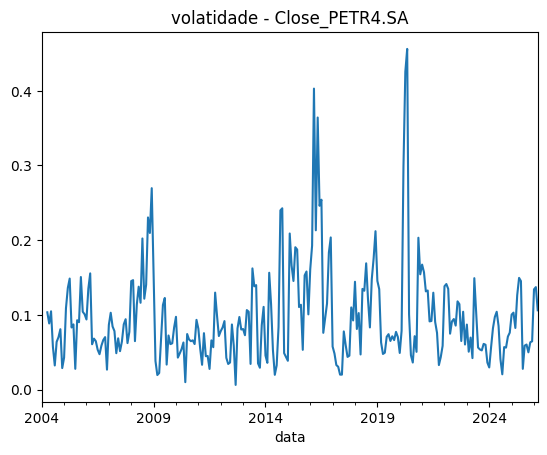

In [6]:
plt.title("volatidade - Close_PETR4.SA")
df['sigma'].plot()

In [7]:
# excluindo os preços para evitar vazamento
df = df.drop('Close_PETR4.SA', axis=1)
df = df.dropna()

In [8]:
df_train = df.loc['2004-01-01':'2024-06-01'] # inicio de 2004 ate o primeiro semestre de 2021 
df_test = df.loc['2024-07-01':'2026-03-01'] # ate março de 2026 

In [9]:
print("dimensoes dos dados")
print("==="*50)
print()
print(f"Dados de treino: linhas -> {df_train.shape[0]} | colunas -> {df_train.shape[1]} | inicio: {df_train.reset_index()['data'].min()} -> final:{df_train.reset_index()['data'].max()}")
print()
print(f"Dados de teste: linhas -> {df_test.shape[0]} | colunas -> {df_test.shape[1]} | inicio: {df_test.reset_index()['data'].min()} -> final:{df_test.reset_index()['data'].max()}")
print()
print("==="*50)

dimensoes dos dados

Dados de treino: linhas -> 243 | colunas -> 14 | inicio: 2004-04-01 00:00:00 -> final:2024-06-01 00:00:00

Dados de teste: linhas -> 21 | colunas -> 14 | inicio: 2024-07-01 00:00:00 -> final:2026-03-01 00:00:00



In [10]:
models = {
    "Arvore_de_decisao": DecisionTreeRegressor(random_state=42), 
    "Gradient_Boosting":GradientBoostingRegressor(random_state=42), 
    "XGBoost": XGBRegressor(),
    "AdaBoost": AdaBoostRegressor(random_state=42)
    
}

In [11]:
# separaçao de x e y (treino)
X_train = df_train.drop('sigma', axis=1)
y_train = df_train['sigma']
y_train = y_train.fillna(y_train.mean())

In [12]:
# x e y (teste)
X_test = df_test.drop('sigma', axis=1)
y_test = df_test['sigma']


# VIF

In [13]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
8,IBC-Br,697.525491
0,Produção de derivados de petróleo,335.530963
6,Producao Industrial,246.604517
1,Consumo de derivados de petróleo - gasolina,97.193755
10,Close_IBOV,75.407442
4,Cambio - IPCA,41.898714
2,Consumo de derivados de petróleo - Óleo combus...,26.067222
3,Selic,19.943118
11,BETA,17.702215
12,regime,4.582017


# Correlaçao das variaveis com o target

In [14]:
corr = df_train.corr()['sigma']
corr

Produção de derivados de petróleo                      0.062870
Consumo de derivados de petróleo - gasolina           -0.008842
Consumo de derivados de petróleo - Óleo combustível   -0.091654
Selic                                                 -0.033779
Cambio - IPCA                                          0.206205
IPCA                                                  -0.000329
Producao Industrial                                   -0.247313
Balança comercial                                     -0.034258
IBC-Br                                                -0.064072
Volume_PETR4.SA                                        0.082541
Close_IBOV                                            -0.040097
BETA                                                   0.367801
regime                                                 0.345007
sigma                                                  1.000000
Name: sigma, dtype: float64

# Teste de Estacionaridade 

In [15]:
for i in X_train.columns:
    p_value = adfuller(X_train[i], autolag='AIC', maxlag=3)[1]
    print(f"{i} -> p_valor: {p_value}")
    if p_value > 0.05:
        print("hipotese nula aceita -> a serie nao é estacionaria")
    else: 
        print("hipotese nula rejeitada -> a serie é estacionaria")
    print()

Produção de derivados de petróleo -> p_valor: 0.9080329997789207
hipotese nula aceita -> a serie nao é estacionaria

Consumo de derivados de petróleo - gasolina -> p_valor: 0.367900072720754
hipotese nula aceita -> a serie nao é estacionaria

Consumo de derivados de petróleo - Óleo combustível -> p_valor: 0.08711038262226295
hipotese nula aceita -> a serie nao é estacionaria

Selic -> p_valor: 0.2564033866304989
hipotese nula aceita -> a serie nao é estacionaria

Cambio - IPCA -> p_valor: 0.24436510954401042
hipotese nula aceita -> a serie nao é estacionaria

IPCA -> p_valor: 2.9390508190897297e-12
hipotese nula rejeitada -> a serie é estacionaria

Producao Industrial -> p_valor: 7.532983723021777e-07
hipotese nula rejeitada -> a serie é estacionaria

Balança comercial -> p_valor: 5.200058758048272e-05
hipotese nula rejeitada -> a serie é estacionaria

IBC-Br -> p_valor: 0.3140389592857547
hipotese nula aceita -> a serie nao é estacionaria

Volume_PETR4.SA -> p_valor: 1.914073449592032

# Plotando grafico de autocorrelaçao 

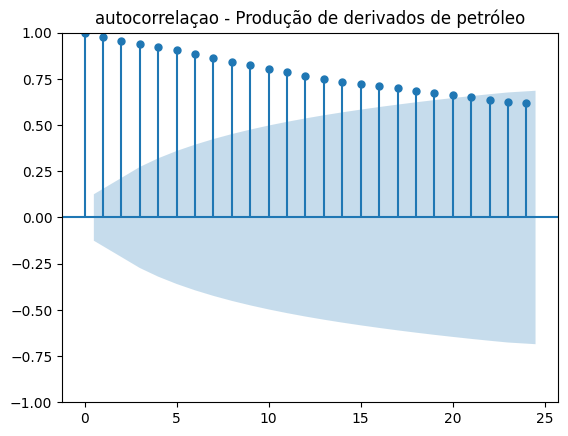

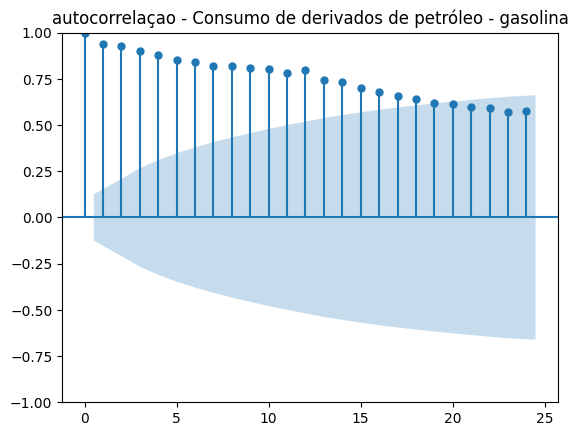

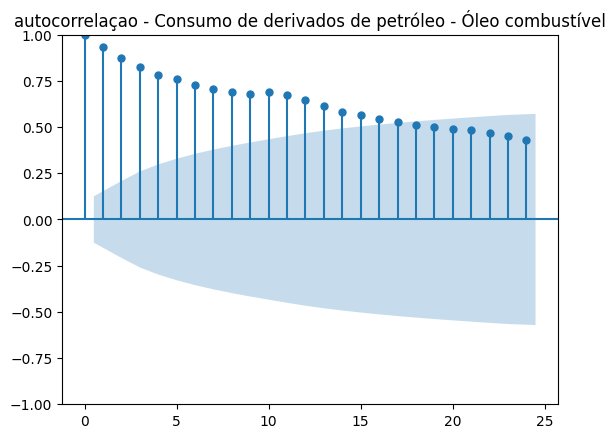

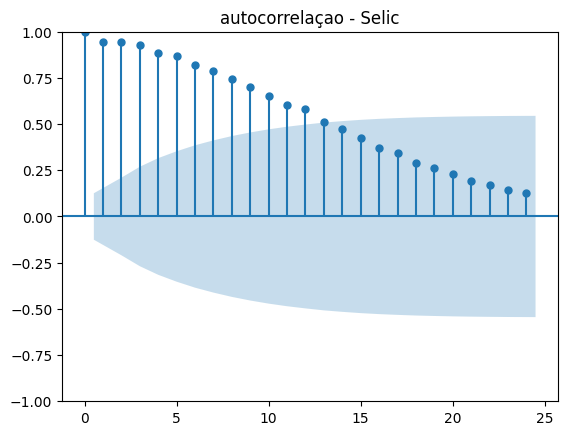

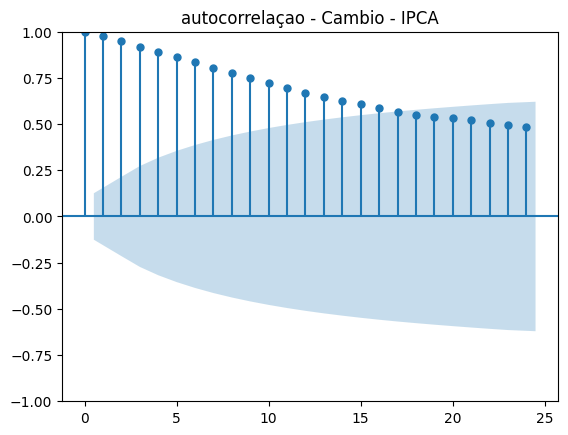

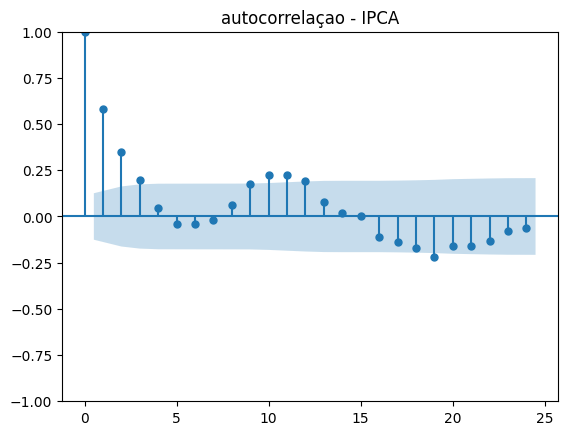

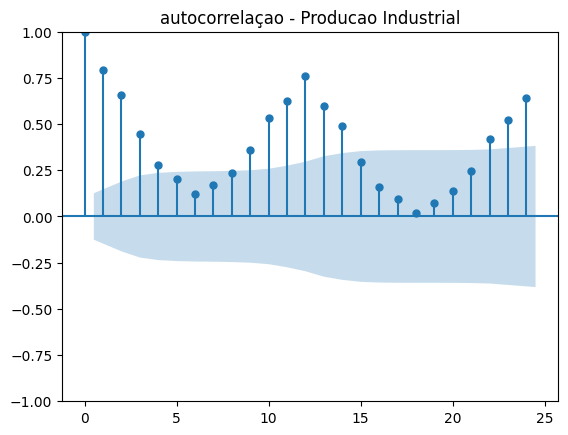

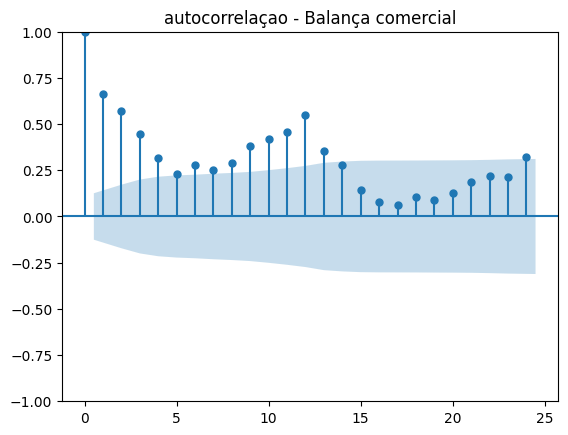

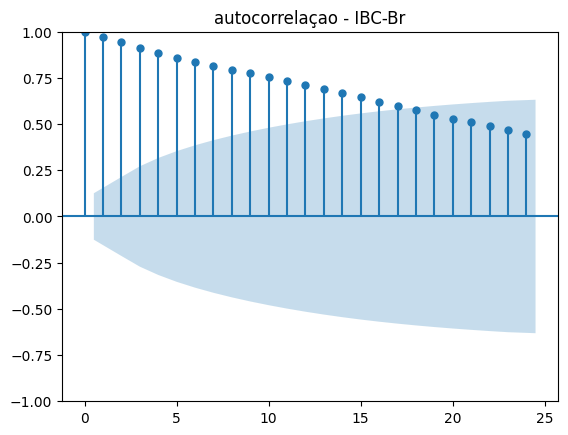

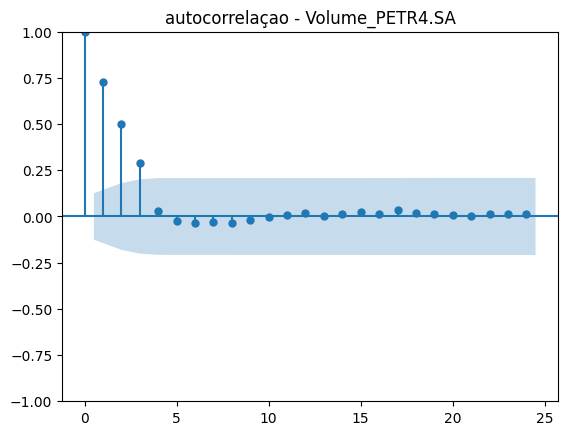

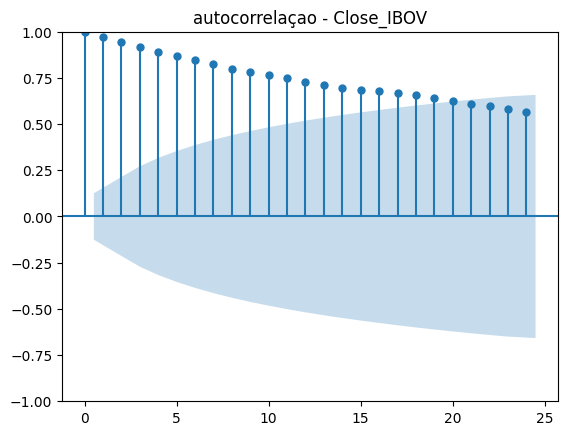

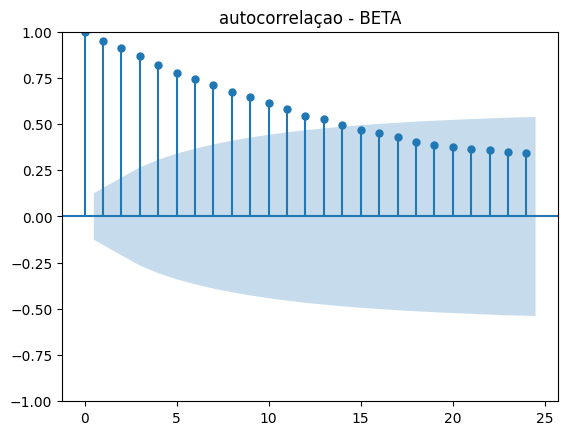

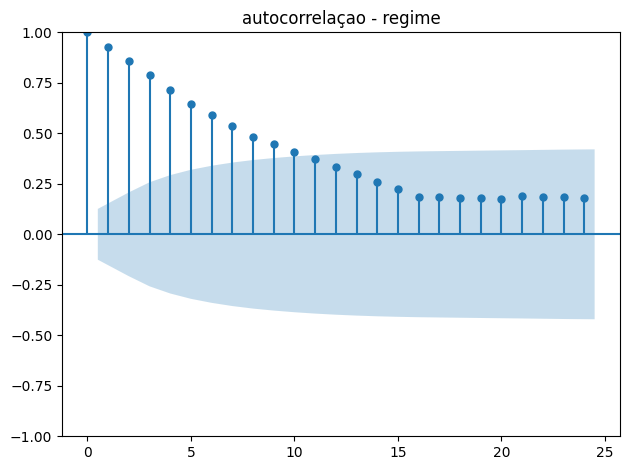

In [16]:
from statsmodels.graphics. tsaplots import plot_acf
for i in X_train.columns:
    plot_acf(x=X_train[i], title=f"autocorrelaçao - {i}")
plt.tight_layout()
plt.show()

# Treinamento 

In [17]:
# funçao para metricas
def metrics(y_true:pd.Series, y_pred:pd.Series) -> pd.DataFrame:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics_dict = {
        "MAE": mae, 
        "MSE": mse, 
        "R2": r2
    }
    return pd.DataFrame([metrics_dict])

Modelo Arvore_de_decisao

 metricas Treino ->    MAE  MSE   R2
0  0.0  0.0  1.0
 metricas Teste ->         MAE      MSE        R2
0  0.047317  0.00357 -1.479181


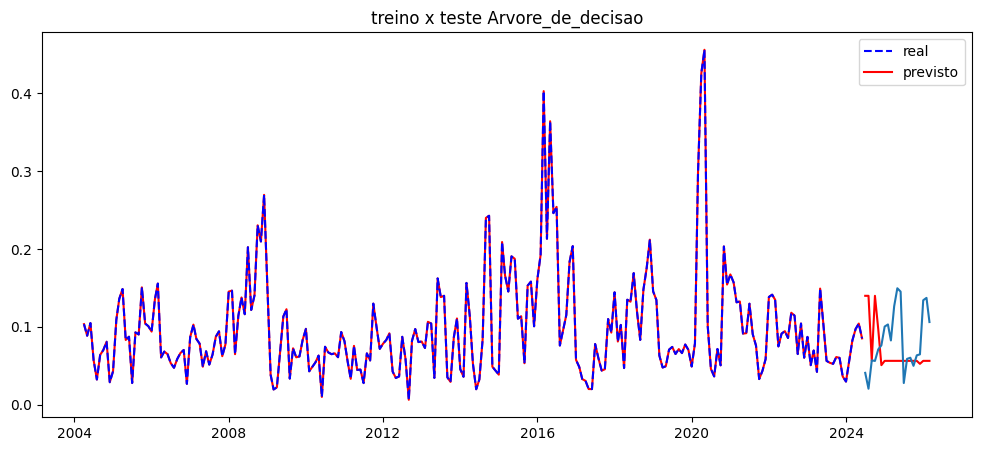

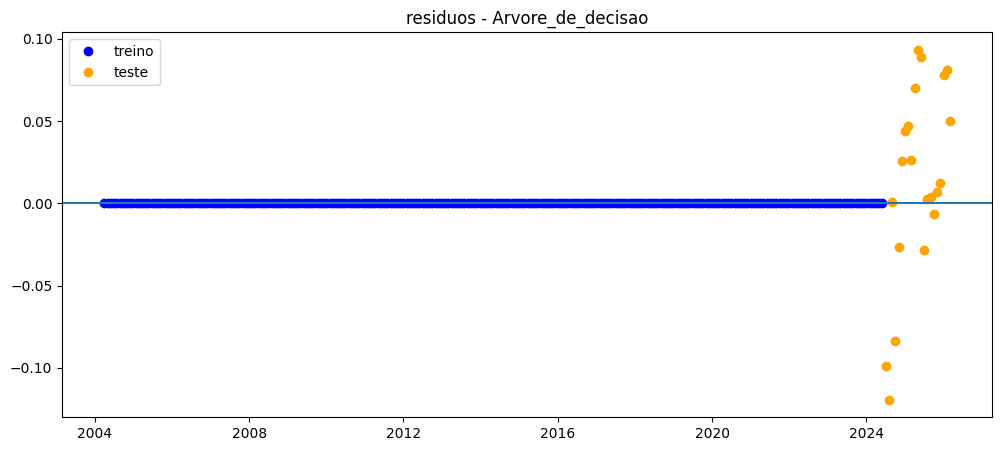

-0.1680493571081192
Modelo Gradient_Boosting

 metricas Treino ->         MAE       MSE        R2
0  0.016571  0.000434  0.901481
 metricas Teste ->         MAE       MSE        R2
0  0.035923  0.002056 -0.427768


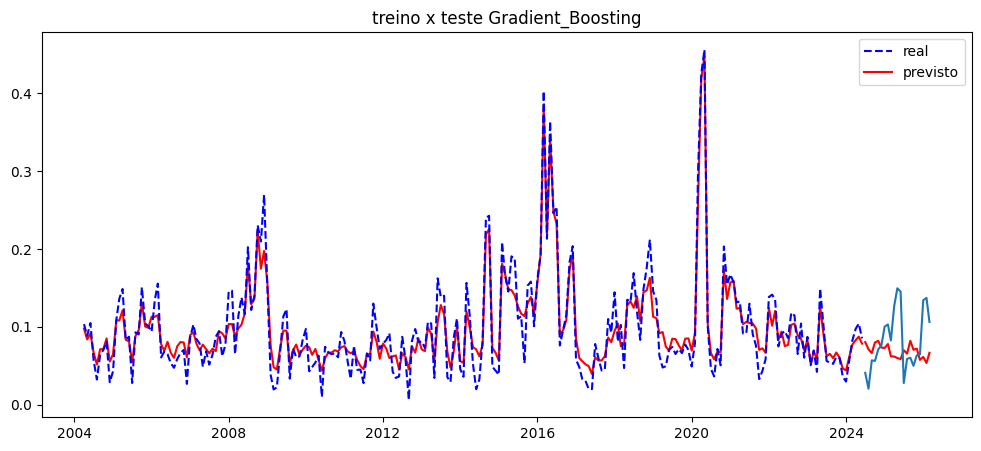

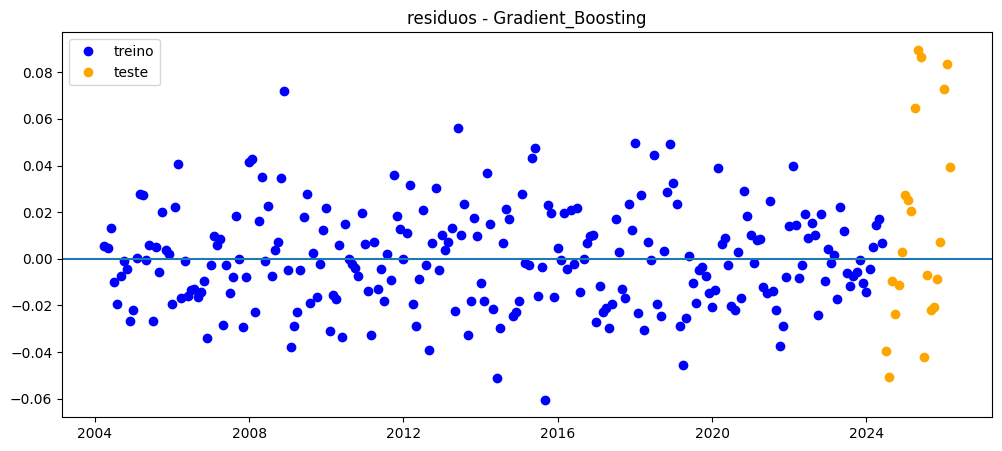

-0.1680493571081192
Modelo XGBoost

 metricas Treino ->         MAE           MSE        R2
0  0.000592  6.714729e-07  0.999848
 metricas Teste ->         MAE     MSE        R2
0  0.038898  0.0025 -0.735892


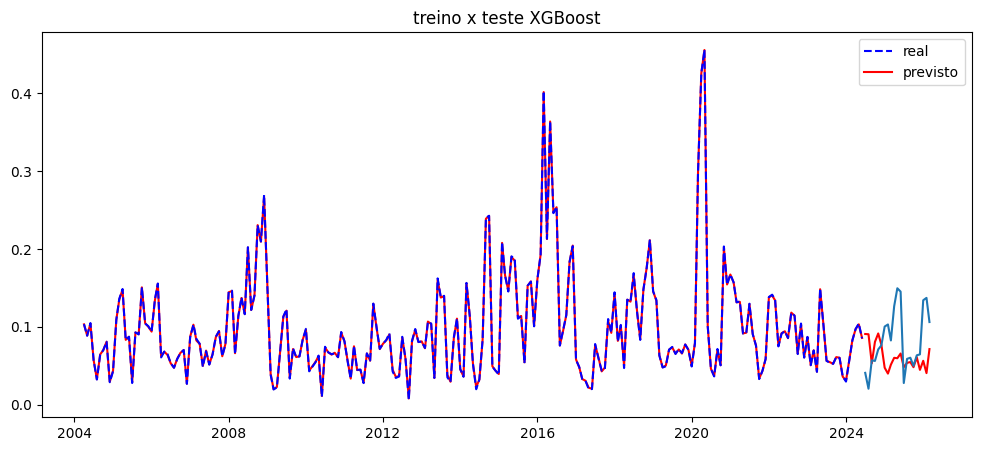

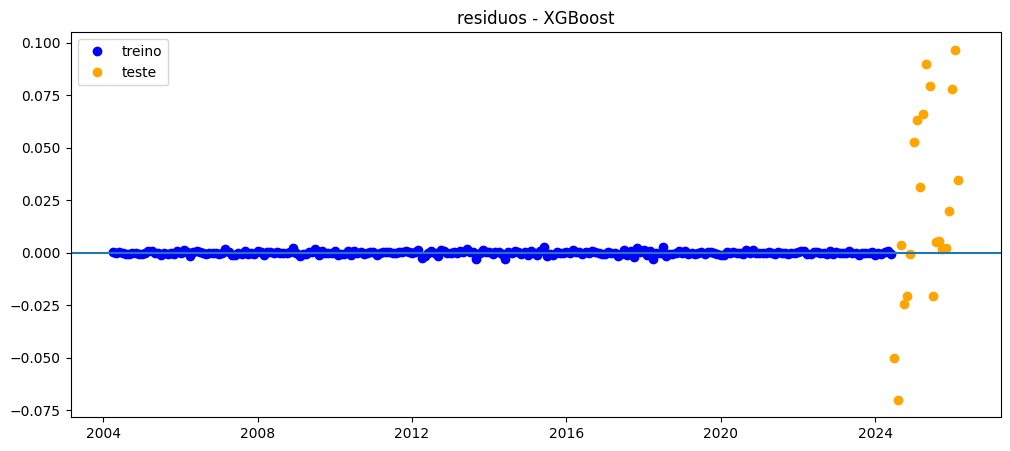

-0.1680493571081192
Modelo AdaBoost

 metricas Treino ->         MAE       MSE        R2
0  0.030802  0.001342  0.695549
 metricas Teste ->         MAE       MSE        R2
0  0.028183  0.001217  0.154881


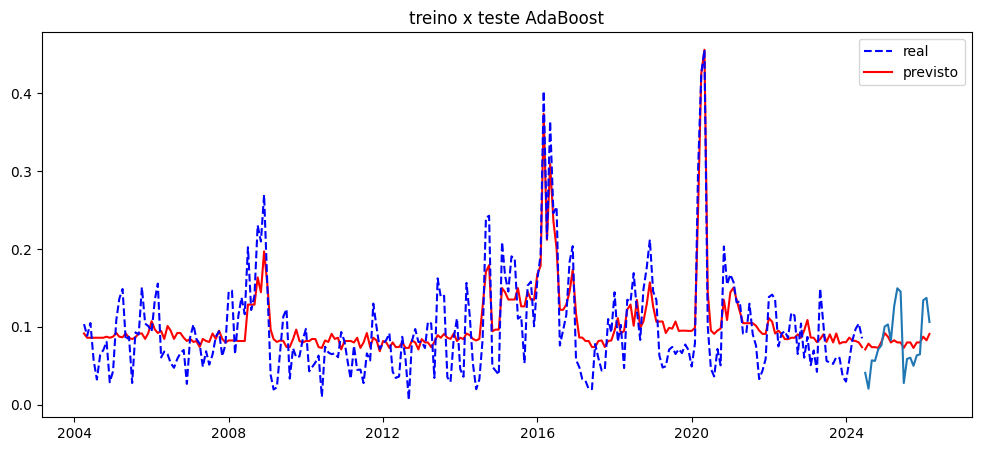

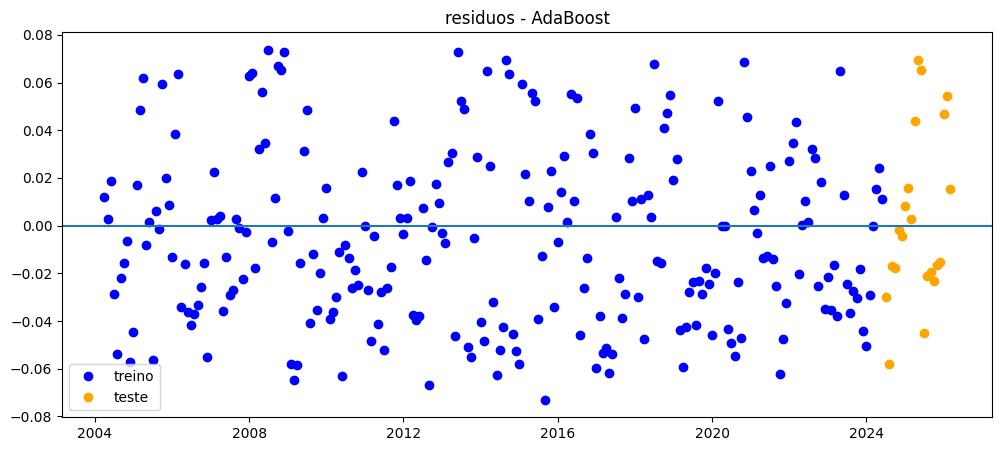

-0.1680493571081192


In [18]:
for i, model in models.items():
    model_ = model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print("==="*20)
    print(f"Modelo {i}")
    print()
    print(f" metricas Treino -> {metrics(y_train, y_pred_train)}")
    print(f" metricas Teste -> {metrics(y_test, y_pred_test)}")
    
    plt.figure(figsize=(12,5))
    plt.title(f'treino x teste {i}')
    plt.plot(y_train.index, y_pred_train, color='red')
    plt.plot(y_train, linestyle='--', color='blue', label='real')
    plt.plot(y_test.index, y_pred_test, color='red', label='previsto')
    plt.plot(y_test)
    plt.legend()
    plt.show()
    
    # calculando residuo 
    resid_train = y_train - y_pred_train
    resid_test = y_test - y_pred_test
    plt.figure(figsize=(12,5))
    plt.title(f'residuos - {i}')
    plt.plot(resid_train, linestyle='none', marker='o', color='blue', label='treino')
    plt.plot(resid_test, linestyle='none', marker='o', color='orange', label='teste')
    plt.axhline(y=0)        
    plt.legend()
    plt.show()
    
    y_pred_baseline = np.full_like(y_test, y_train.mean())

    print(r2_score(y_test, y_pred_baseline))

# Modelo ARDL 

In [19]:
model_ardl = ARDL(y_train, lags=3, exog=X_train, order=2).fit()
print(model_ardl.summary())

                                            ARDL Model Results                                            
Dep. Variable:                                              sigma   No. Observations:                  243
Model:             ARDL(3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)   Log Likelihood                 414.127
Method:                                           Conditional MLE   S.D. of innovations              0.043
Date:                                            Thu, 07 May 2026   AIC                           -740.254
Time:                                                    15:46:54   BIC                           -587.106
Sample:                                                07-01-2004   HQIC                          -678.547
                                                     - 06-01-2024                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------

c:\Users\souza\OneDrive\Documentos\signal_project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


as features que realmente se mostraram significativas no ARDL sao: IBC-Br e BETA. O restante se tornou ruido 

In [20]:
select_cols = ['IBC-Br', 'BETA']
X_select = X_train[select_cols]
new_ardl = ARDL(endog=y_train, lags=[1,3],exog=X_select, order=1, trend='n').fit()
print(new_ardl.summary())

                              ARDL Model Results                              
Dep. Variable:                  sigma   No. Observations:                  243
Model:                  ARDL(3, 1, 1)   Log Likelihood                 391.478
Method:               Conditional MLE   S.D. of innovations              0.047
Date:                Thu, 07 May 2026   AIC                           -768.956
Time:                        15:46:55   BIC                           -744.591
Sample:                    07-01-2004   HQIC                          -759.139
                         - 06-01-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma.L1       0.5717      0.051     11.216      0.000       0.471       0.672
sigma.L3      -0.1535      0.052     -2.962      0.003      -0.256      -0.051
IBC-Br.L0     -0.0155      0.003     -5.346      0.0

c:\Users\souza\OneDrive\Documentos\signal_project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Com a poda do modelo e das features, consegui metricas melhores e mais ajustadas: 

- p_valores significativos 

- persistencia temporal entre os lags 

- aic e bic consistentes

# Previsoes ARDL

c:\Users\souza\OneDrive\Documentos\signal_project\venv\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


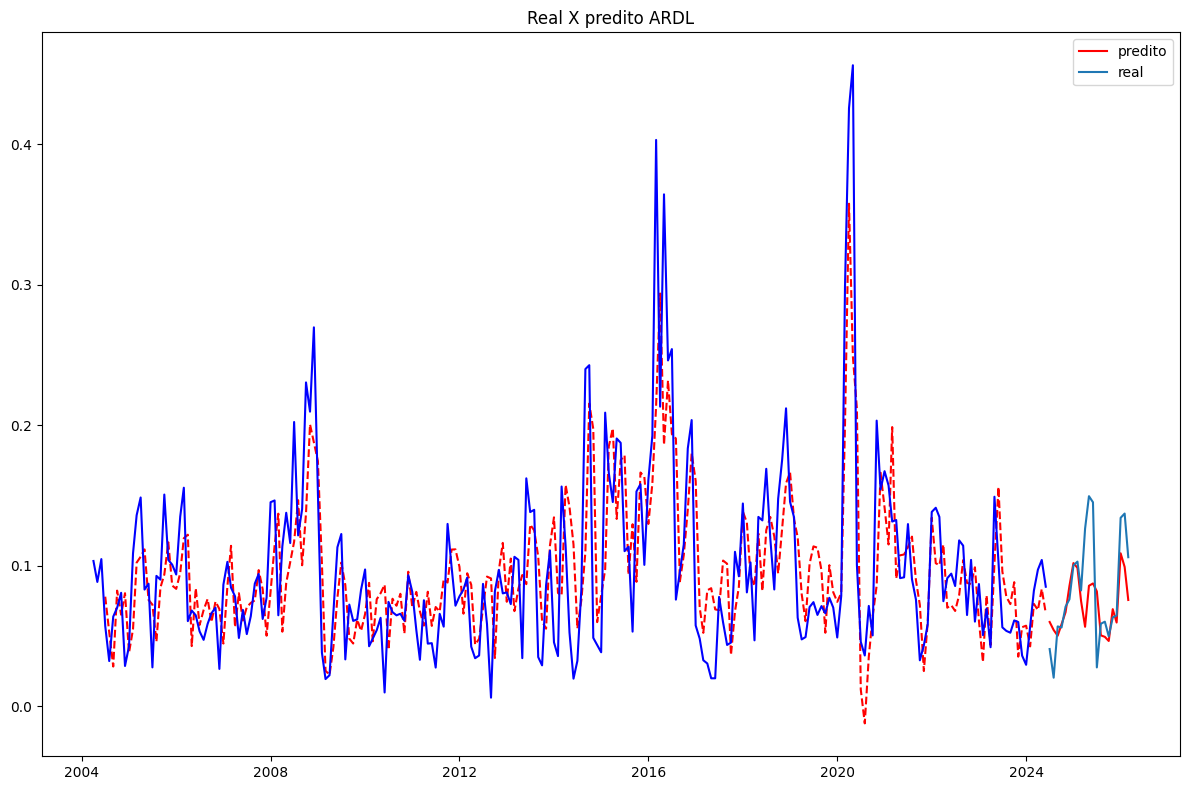

metricas - ardl
        MAE       MSE        R2
0  0.021965  0.000962  0.331669


In [21]:
pred_ardl = new_ardl.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog_oos=X_test[select_cols])
pred_train_ardl = new_ardl.predict(start=0, end=len(y_train)-1, exog=X_train[select_cols])

plt.figure(figsize=(12,8))
plt.title("Real X predito ARDL")
plt.plot(pred_train_ardl, color='red', linestyle='--')
plt.plot(y_train, color='blue')
plt.plot(pred_ardl, label='predito', color='red')
plt.plot(y_test, label='real')
plt.tight_layout()
plt.legend()
plt.show()

print(f"metricas - ardl")
print(metrics(y_test, pred_ardl))

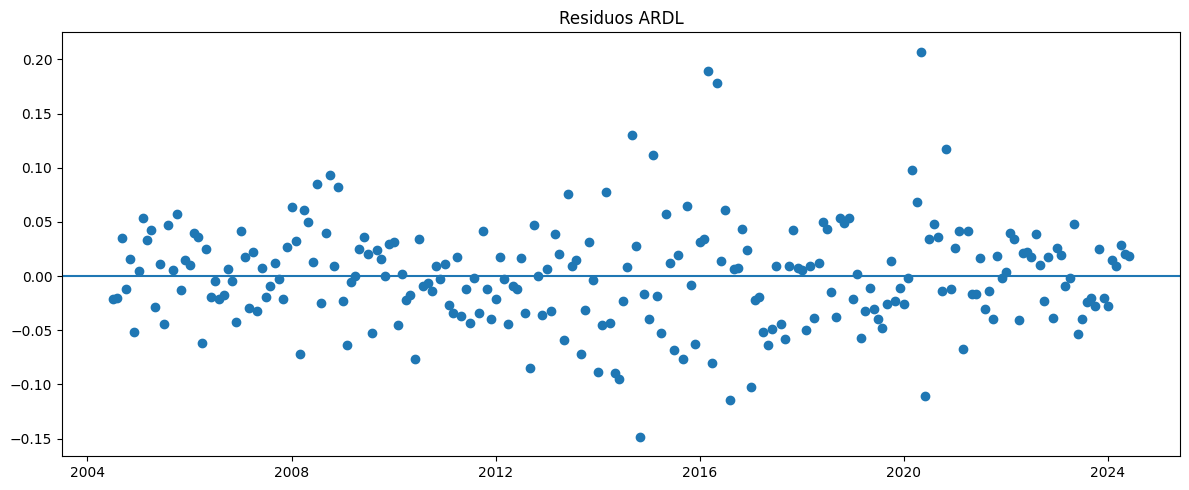

<Figure size 1200x500 with 0 Axes>

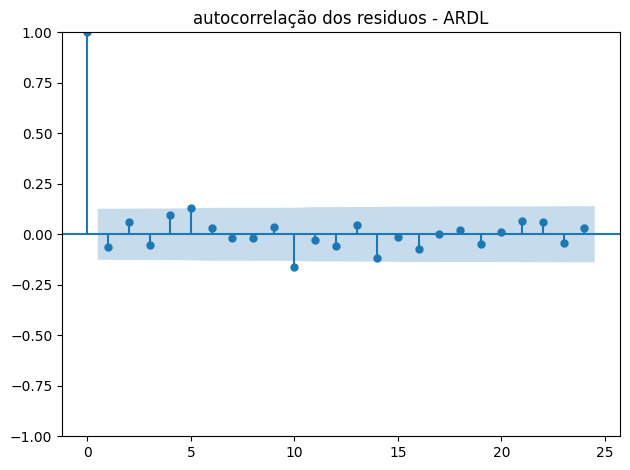

In [22]:
# residuos e autocorrelaçao dos residuos 
n = new_ardl.resid
plt.figure(figsize=(12,5))
plt.title('Residuos ARDL')
plt.plot(n, marker='o', linestyle='none')
plt.axhline(y=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plot_acf(n, title='autocorrelação dos residuos - ARDL')
plt.tight_layout()
plt.show()

# Teste de Heterocesdasticidade

Se p_valor > 0.05 -> Não rejeita a hipotese nula (há heterocedasticidade)

Se p_valor < 0.05 -> Rejeita a hipotese nula (não há heterocedasticidade)

In [23]:
# het_breuschpagan
def het_breuschpagan_test(resid:pd.Series, exog) -> pd.DataFrame:
    resid = pd.Series(resid)
    df = pd.concat([resid, exog], axis=1).dropna()
    exog_clean = df.iloc[:, 1:]
    resid_clean = df.iloc[:, 0]
    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid_clean,sm.add_constant(exog_clean), robust=True)
    if lm_pvalue < 0.05 and f_pvalue <0.05:
        print('hipotese nula rejeitada -> Não há evidencias estatisticas de heterocedasticidade')
    else:
        print('hipotese nula aceita -> Há evidencias estatisticas de heterocedasticidade')
    out_test = {
        'lm':lm, 
        'lm_pvalue':lm_pvalue,
        'fvalue':fvalue, 
        'f_pvalue': f_pvalue
    }
    return pd.DataFrame([out_test])

In [24]:
het_breuschpagan_test(new_ardl.resid, X_train[select_cols])

hipotese nula rejeitada -> Não há evidencias estatisticas de heterocedasticidade


,lm,lm_pvalue,fvalue,f_pvalue
0,27.948223,8.533368e-07,15.618188,4.249472e-07


fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X_train['IBC-Br'].values, X_train['BETA'].values, y_train.values, cmap='viridis', lightsource=True)
ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('volatilidade')
fig.tight_layout()
fig.show()

fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train['IBC-Br'].values, X_train['BETA'].values, y_train.values, cmap='viridis', c=y_train.values)
ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('volatilidade')
fig.tight_layout()
fig.show()


# Verificando normalidade dos residuos

C:\Users\souza\AppData\Local\Temp\ipykernel_14040\3127831867.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_qq.show()


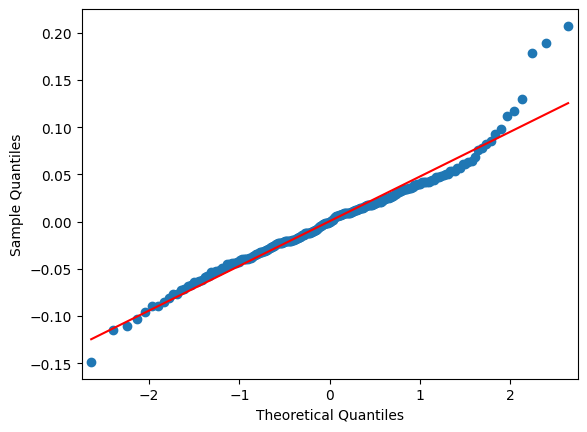

In [ ]:
# qq plot 
fig_qq = qqplot(new_ardl.resid, line='s')
fig_qq.show()


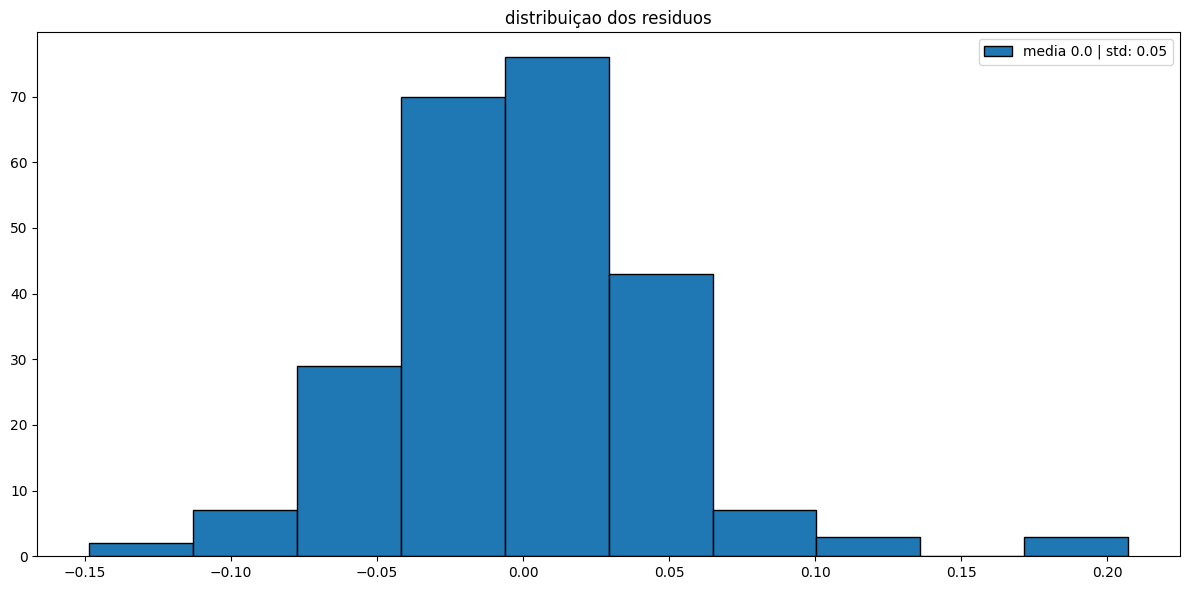

In [51]:
# distribuiçao dos residuos
fig = plt.figure(figsize=(12,6))
plt.title('distribuiçao dos residuos')
plt.hist(new_ardl.resid, edgecolor='black', label=f'media {np.round(np.mean(n),2)} | std: {np.round(np.std(n),2)}')
plt.legend()
plt.tight_layout()
plt.show()

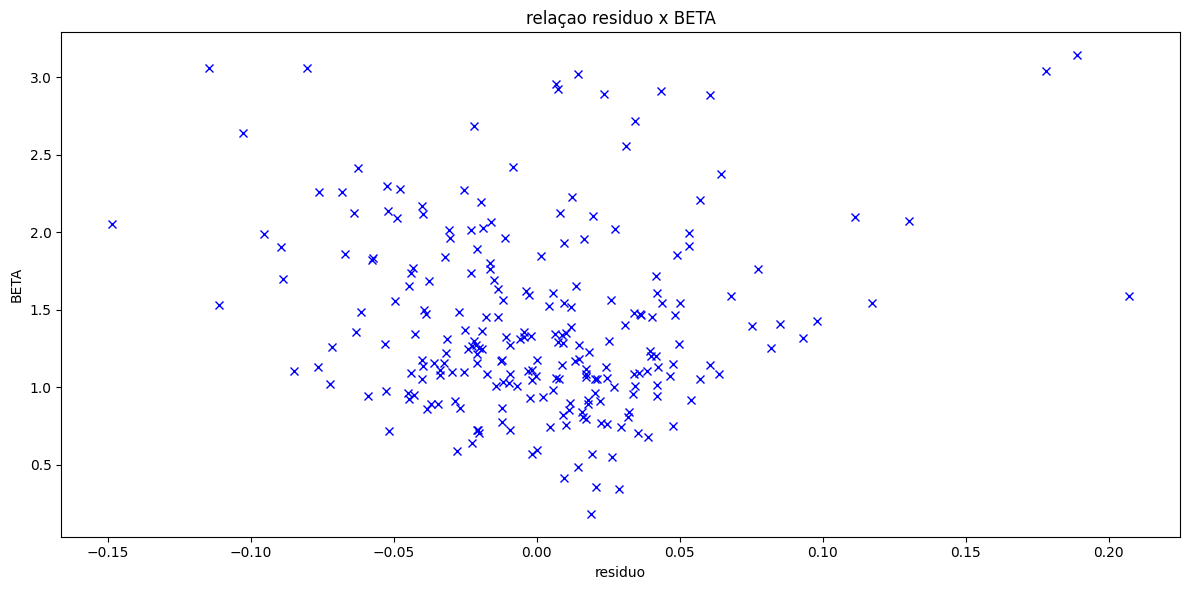

In [74]:
# comparando residuo com o beta para verificar linearidade
df_ = pd.concat([n, X_select], axis=1).dropna()
plt.figure(figsize=(12,6))
plt.title('relaçao residuo x BETA')
plt.plot(df_[0], df_['BETA'], marker='x', linestyle='none', color='blue')
plt.xlabel('residuo')
plt.ylabel('BETA')

plt.tight_layout()
plt.show()

Não há linearidade entre os residuos e o BETA

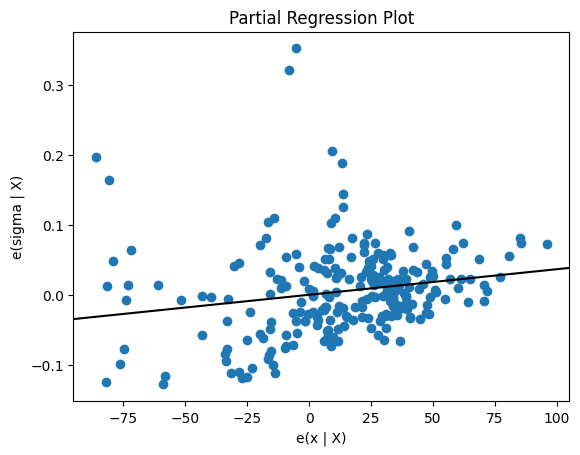

<Figure size 1200x800 with 0 Axes>

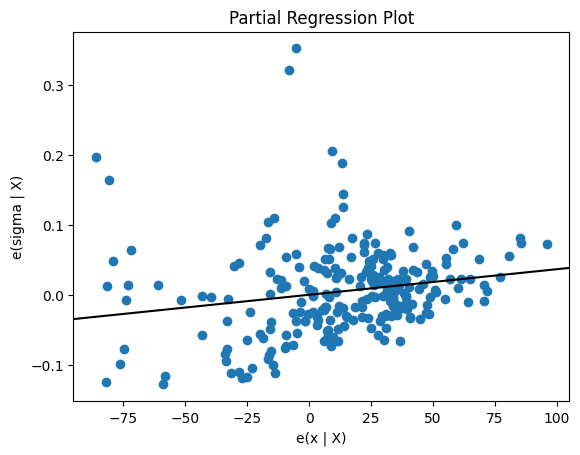

In [88]:
plt.figure(figsize=(12,8))
sm.graphics.plot_partregress(y_train, new_ardl.model.exog[:,0], new_ardl.model.exog[:,1:], obs_labels=False)


# Jarque Bera

Se o valor de Jarque bera estiver muito distante de 0, indica que os dados nao seguem uma distribuiçao normal

In [103]:
from scipy.stats import jarque_bera

print("---- Teste Jarque Bera ----")
print()
jb_pvalue = jarque_bera(new_ardl.resid)[1]
jb_stats = jarque_bera(new_ardl.resid)[0]
print(f'pvalor -> {jb_pvalue}')
print()
if jb_pvalue <0.05:
    print('{Hipotese nula rejeitada H[0] -> Não há evidencias de normalidade por Jarque Bera -> H[1]}')
else: 
    print('Hipotese nula aceita H[0]-> Há evidencias de normalidade por Jarque Bera -> H[0]')
print()
print(f'Valor de Jarque Bera -> {jb_stats}')
print('----'*50)

---- Teste Jarque Bera ----

pvalor -> 1.4345401641367647e-20

{Hipotese nula rejeitada H[0] -> Não há evidencias de normalidade por Jarque Bera -> H[1]}

Valor de Jarque Bera -> 91.38171501026493
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
